In [6]:
!pip install mne
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.datasets.sleep_physionet.temazepam import fetch_data

files=fetch_data(subjects=[0])
print(files)

Using default location ~/mne_data for PHYSIONET_SLEEP...
Creating /root/mne_data


  0%|                                              | 0.00/29.4M [00:00<?, ?B/s]

  0%|                                              | 0.00/6.36k [00:00<?, ?B/s]

Download complete in 01m54s (28.1 MB)
[['/root/mne_data/physionet-sleep-data/ST7011J0-PSG.edf', '/root/mne_data/physionet-sleep-data/ST7011JP-Hypnogram.edf']]


In [5]:
help(fetch_data) #つまりrecordingがあると思ったら、無かった。

Help on function fetch_data in module mne.datasets.sleep_physionet.temazepam:

fetch_data(subjects, path=None, force_update=False, base_url='https://physionet.org/physiobank/database/sleep-edfx/sleep-telemetry/', *, verbose=None)
    Get paths to local copies of PhysioNet Polysomnography dataset files.

    This will fetch data from the publicly available subjects from PhysioNet's
    study of Temazepam effects on sleep :footcite:`KempEtAl2000`. This
    corresponds to a set of 22 subjects. Subjects had mild difficulty falling
    asleep but were otherwise healthy.

    See more details in the `physionet website
    <https://physionet.org/physiobank/database/sleep-edfx/>`_
    :footcite:`GoldbergerEtAl2000`.

    Parameters
    ----------
    subjects : list of int
        The subjects to use. Can be in the range of 0-21 (inclusive).
    path : None | str
        Location of where to look for the PhysioNet data storing location.
        If None, the environment variable or config param

In [9]:
raw=mne.io.read_raw_edf(files[0][0],preload=True)
annotations=mne.read_annotations(files[0][1])
raw.set_annotations(annotations)

print(raw.info)
print(annotations)

Extracting EDF parameters from /root/mne_data/physionet-sleep-data/ST7011J0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...


/tmp/ipykernel_12450/1506527509.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw=mne.io.read_raw_edf(files[0][0],preload=True)
/tmp/ipykernel_12450/1506527509.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw=mne.io.read_raw_edf(files[0][0],preload=True)


Reading 0 ... 3589999  =      0.000 ... 35899.990 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, EMG submental, Marker
 chs: 5 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 800.0 Hz
 meas_date: 1994-07-12 23:00:00 UTC
 nchan: 5
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, first_name: Male, last_name: 60yr>
>
<Annotations | 231 segments: Sleep stage 1 (52), Sleep stage 2 (82), Sleep ...>


In [8]:
print(files)
print(len(files))

[['/root/mne_data/physionet-sleep-data/ST7011J0-PSG.edf', '/root/mne_data/physionet-sleep-data/ST7011JP-Hypnogram.edf']]
1


In [17]:
EEG_CHANNELS_BDF=['EEG Fpz-Cz', 'EEG Pz-Oz']
L_FREQ=0.5
H_FREQ=30.0
F_MAX=30.0

raw_filtered=raw.copy().filter(l_freq=L_FREQ, h_freq=H_FREQ)
raw_filtered.pick(EEG_CHANNELS_BDF)

rem_annotations=[a for a in annotations if 'R' in a['description']]
nrem_annotations=[a for a in annotations if '2' in a ['description']]

print(f"REM annotations: {len(rem_annotations)}")
print(f"NREM annotations: {len(nrem_annotations)}")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (6.610 s)

REM annotations: 10
NREM annotations: 82


Effective window size : 20.480 (s)
Effective window size : 20.480 (s)


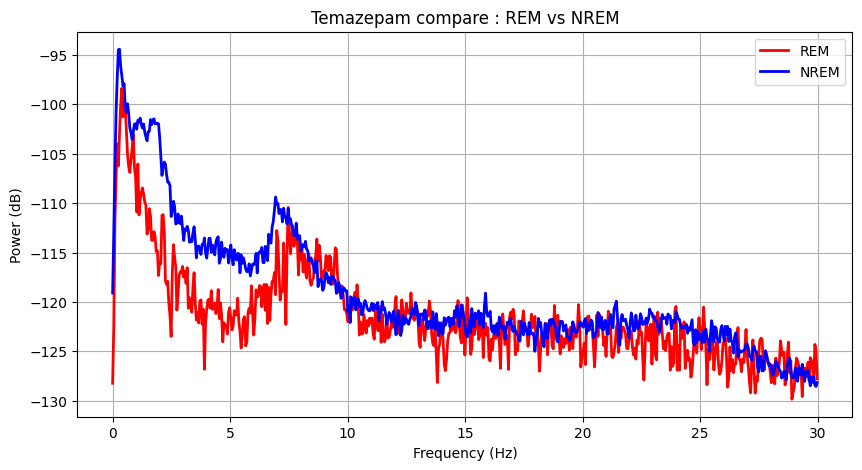

In [19]:
onset_rem=rem_annotations[0]['onset'] #7からの流用
duration_rem=rem_annotations[0]['duration']
rem_raw=raw_filtered.copy().crop(tmin=onset_rem, tmax=onset_rem+duration_rem)

onset_nrem=nrem_annotations[0]['onset']
duration_nrem=nrem_annotations[0]['duration']
nrem_raw=raw_filtered.copy().crop(tmin=onset_nrem, tmax=onset_nrem+duration_nrem)

psd_rem=rem_raw.compute_psd(fmax=H_FREQ)
psd_nrem=nrem_raw.compute_psd(fmax=H_FREQ)

freqs=psd_rem.freqs
power_rem=psd_rem.get_data().mean(axis=0)
power_nrem=psd_nrem.get_data().mean(axis=0)

plt.figure(figsize=(10,5))
plt.plot(freqs, 10*np.log10(power_rem), label='REM', color='red', linewidth=2)
plt.plot(freqs, 10*np.log10(power_nrem), label='NREM', color='blue', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.title('Temazepam compare : REM vs NREM')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
from mne.datasets.sleep_physionet.age import fetch_data as fetch_age
files_placebo=fetch_age(subjects=[0], recording=[1])
raw_placebo=mne.io.read_raw_edf(files_placebo[0][0],preload=True)
annotations_placebo=mne.read_annotations(files_placebo[0][1])
raw_placebo.set_annotations(annotations_placebo)

EEG_CHANNELS_BDF=['EEG Fpz-Cz', 'EEG Pz-Oz']
L_FREQ=0.5
H_FREQ=30.0
F_MAX=30.0

raw_placebo_filtered=raw_placebo.copy().filter(l_freq=L_FREQ, h_freq=H_FREQ)
raw_placebo_filtered.pick(EEG_CHANNELS_BDF)
print("placebo data loading complete")

Using default location ~/mne_data for PHYSIONET_SLEEP...


  0%|                                              | 0.00/48.3M [00:00<?, ?B/s]

  0%|                                              | 0.00/4.62k [00:00<?, ?B/s]

Download complete in 03m29s (46.1 MB)
Extracting EDF parameters from /root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


/tmp/ipykernel_12450/989219135.py:3: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_placebo=mne.io.read_raw_edf(files_placebo[0][0],preload=True)
/tmp/ipykernel_12450/989219135.py:3: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_placebo=mne.io.read_raw_edf(files_placebo[0][0],preload=True)
/tmp/ipykernel_12450/989219135.py:3: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw_placebo=mne.io.read_raw_edf(files_placebo[0][0],preload=True)
/tmp/ipykernel_12450/989219135.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_placebo.set_annotations(annotations_placebo)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (6.610 s)

placebo data loading complete


Effective window size : 20.480 (s)
Effective window size : 20.480 (s)


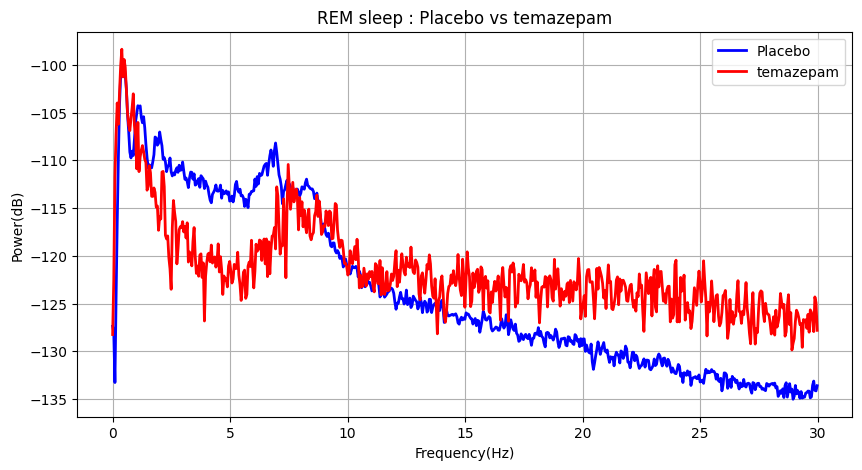

In [27]:
rem_annotations_placebo=[a for a in annotations_placebo if 'R' in a['description']]
onset_placebo=rem_annotations_placebo[0]['onset']
duration_placebo=rem_annotations_placebo[0]['duration']
rem_placebo=raw_placebo_filtered.copy().crop(tmin=onset_placebo, tmax=onset_placebo+duration_placebo)

rem_annotations_tmz=[a for a in annotations_placebo if 'R' in a['description']]
onset_tmz=rem_annotations[0]['onset']
duration_tmz=rem_annotations[0]['duration']
rem_tmz=raw_filtered.copy().crop(tmin=onset_tmz, tmax=onset_tmz+duration_tmz)

psd_placebo=rem_placebo.compute_psd(fmax=H_FREQ)
psd_tmz=rem_tmz.compute_psd(fmax=H_FREQ)

freqs=psd_placebo.freqs
power_placebo=psd_placebo.get_data().mean(axis=0)
power_tmz=psd_tmz.get_data().mean(axis=0)

plt.figure(figsize=(10,5))
plt.plot(freqs, 10*np.log10(power_placebo), label='Placebo', color='blue', linewidth=2)
plt.plot(freqs, 10*np.log10(power_tmz), label='temazepam', color='red', linewidth=2)
plt.xlabel('Frequency(Hz)')
plt.ylabel('Power(dB)')
plt.title('REM sleep : Placebo vs temazepam')
plt.legend()
plt.grid(True)
plt.show()